# Task 3 -- Cuisine Classification
### Restaurant Intelligence Suite | Cognifyz Technologies ML Internship

## 1. Introduction
This notebook predicts a restaurant's **primary cuisine category** from its non-cuisine
attributes (location, cost, service options, rating, votes).

## 2. Business Problem
New restaurant listings sometimes arrive with incomplete or messy cuisine tags. A classifier that
infers the likely primary cuisine from other structured fields can auto-suggest tags for data
quality control, and helps analysts segment restaurants when cuisine text is unreliable.

## 3. Objective
Train and compare multiple classifiers to predict `Primary Cuisine`, handle class imbalance
sensibly, and report per-class performance.


In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from utils import load_dataset, dataset_summary, set_plot_style, save_fig
from preprocessing import clean_dataset, cap_outliers, encode_categorical, scale_features
from feature_engineering import build_feature_set
from visualization import plot_confusion_matrix, plot_model_comparison, plot_top_categories
from models import get_classification_models, train_and_compare

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib

set_plot_style()
RANDOM_STATE = 42


## 4. Dataset Understanding

In [2]:
df_raw = load_dataset('../data/restaurant_dataset.csv')
df = clean_dataset(df_raw)
df = build_feature_set(df)  # adds Primary Cuisine, Cuisine Count, etc.
print(f"Shape: {df.shape}")
print(f"Unique 'Cuisines' combinations: {df['Cuisines'].nunique()}")
print(f"Unique 'Primary Cuisine' values: {df['Primary Cuisine'].nunique()}")


Shape: (9551, 32)
Unique 'Cuisines' combinations: 1826
Unique 'Primary Cuisine' values: 120


**Handling multiple cuisines correctly:** the raw `Cuisines` column is a comma-separated,
multi-label field (e.g. "French, Japanese, Desserts") with 1,800+ unique combinations -- far too
sparse to classify directly. We use **`Primary Cuisine`** (the first-listed cuisine, added in
feature engineering) as a clean single-label target, and further restrict to the **top 15 most
frequent primary cuisines** to keep classes statistically learnable; all other cuisines are
grouped into an `Other` class.

## 5. Data Cleaning

In [3]:
df = cap_outliers(df, 'Average Cost for two')
df = cap_outliers(df, 'Votes')

TOP_N_CUISINES = 15
top_cuisines = df['Primary Cuisine'].value_counts().head(TOP_N_CUISINES).index
df['Cuisine Target'] = df['Primary Cuisine'].where(df['Primary Cuisine'].isin(top_cuisines), 'Other')
print(df['Cuisine Target'].value_counts())


Capped 118 outliers in 'Average Cost for two' to [10.0, 3400.0].
Capped 96 outliers in 'Votes' to [0.0, 1882.5].
Cuisine Target
North Indian    2992
Other           1528
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Name: count, dtype: int64


## 6. Exploratory Data Analysis

Figure saved -> ../outputs/figures/task3_cuisine_class_distribution.png


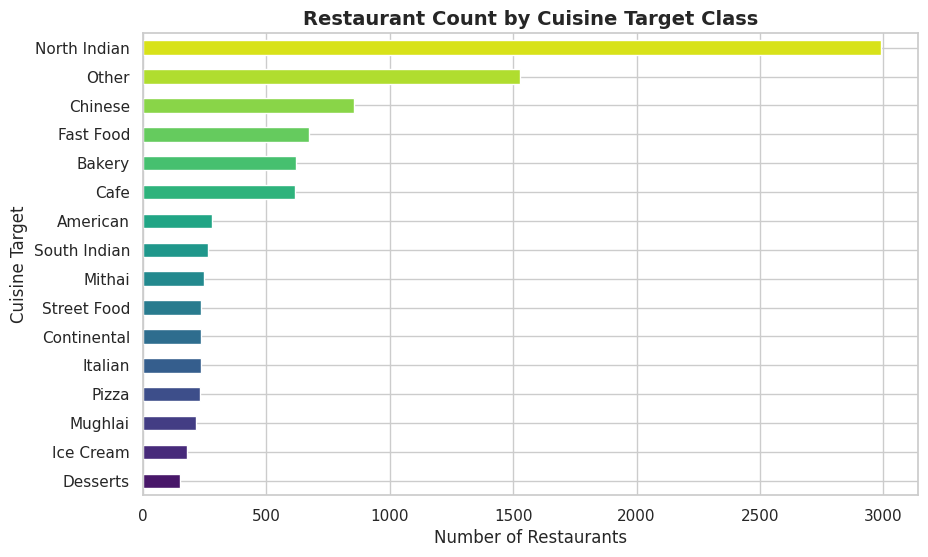

In [4]:
fig = plot_top_categories(df, 'Cuisine Target', top_n=16, title='Restaurant Count by Cuisine Target Class')
save_fig(fig, 'task3_cuisine_class_distribution')
plt.show()


**Insight:** The class distribution is imbalanced -- North Indian and Chinese dominate, while many cuisines each represent under 2% of restaurants. This is addressed via `class_weight='balanced'`-style handling where supported and weighted F1/precision/recall reporting so minority classes are not masked by majority-class accuracy.

Figure saved -> ../outputs/figures/task3_avg_rating_by_cuisine.png


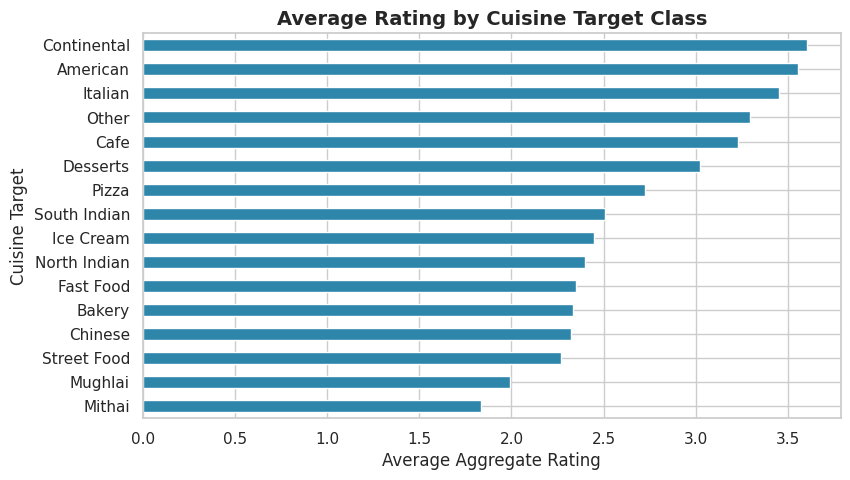

In [5]:
fig, ax = plt.subplots(figsize=(9,5))
df.groupby('Cuisine Target')['Aggregate rating'].mean().sort_values().plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Average Rating by Cuisine Target Class')
ax.set_xlabel('Average Aggregate Rating')
save_fig(fig, 'task3_avg_rating_by_cuisine')
plt.show()


**Insight:** Average ratings vary modestly across cuisine classes, suggesting cuisine type alone is a weak rating driver -- consistent with Task 1's finding that engagement (votes) and price tier matter more than category.

## 7. Feature Engineering & Class Imbalance Analysis

In [6]:
imbalance_ratio = df['Cuisine Target'].value_counts().max() / df['Cuisine Target'].value_counts().min()
print(f"Majority:minority class imbalance ratio: {imbalance_ratio:.1f} : 1")


Majority:minority class imbalance ratio: 19.9 : 1


## 8. Model Development

In [7]:
categorical_cols = ['City']
df_encoded, encoders = encode_categorical(df, categorical_cols, method='label')

feature_cols = [
    'Average Cost for two', 'Price range', 'Votes', 'Aggregate rating',
    'Has Table booking (binary)', 'Has Online delivery (binary)',
    'Cuisine Count', 'City_encoded', 'Longitude', 'Latitude'
]
target_col = 'Cuisine Target'

X = df_encoded[feature_cols]

# XGBoost's sklearn API requires integer class labels (0..K-1), so we label-encode the target.
# The mapping is stored in `target_encoder` and used to decode predictions back to cuisine names
# for the classification report / confusion matrix below.
from sklearn.preprocessing import LabelEncoder
target_encoder = LabelEncoder()
y = pd.Series(target_encoder.fit_transform(df_encoded[target_col]), index=df_encoded.index, name=target_col)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

X_train_scaled, scaler = scale_features(X_train, feature_cols, method='standard')
X_test_scaled = X_test.copy()
X_test_scaled[feature_cols] = scaler.transform(X_test[feature_cols])

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (7640, 10), Test: (1911, 10)


In [8]:
models = get_classification_models(random_state=RANDOM_STATE)
results_df, fitted_models = train_and_compare(models, X_train_scaled, y_train, X_test_scaled, y_test, task='classification')
results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.400837,0.361038,0.400837,0.357775
1,Random Forest,0.400837,0.331695,0.400837,0.334937
2,Decision Tree,0.357928,0.314157,0.357928,0.322222
3,Logistic Regression,0.360021,0.264250,0.360021,0.248643


## 9. Model Evaluation

Figure saved -> ../outputs/figures/task3_model_comparison_f1.png


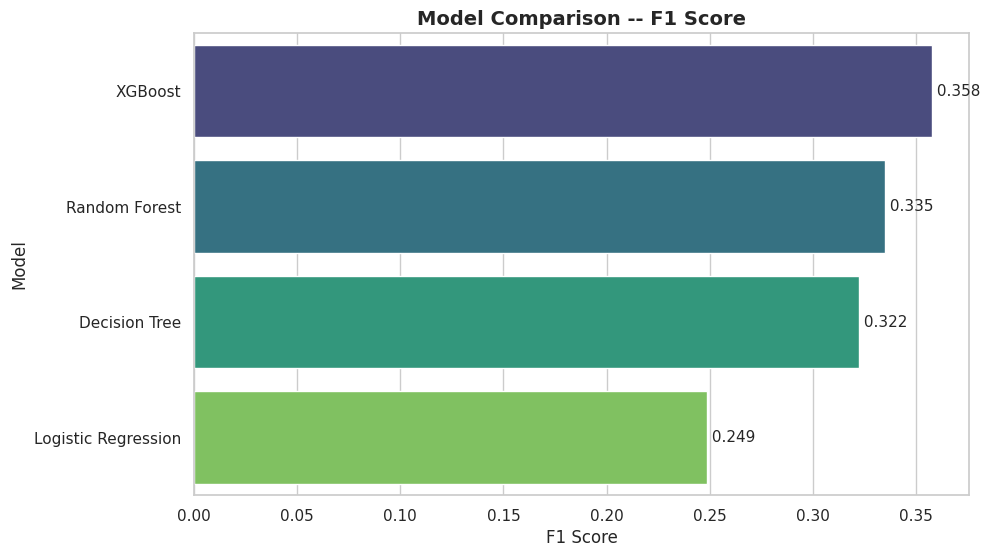

In [9]:
fig = plot_model_comparison(results_df, metric='F1 Score')
save_fig(fig, 'task3_model_comparison_f1')
plt.show()


In [10]:
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]
y_pred_best_enc = best_model.predict(X_test_scaled)

# Decode integer-encoded labels back to human-readable cuisine names for reporting
y_test_labels = target_encoder.inverse_transform(y_test)
y_pred_labels = target_encoder.inverse_transform(y_pred_best_enc)

print(f"Best model: {best_model_name}\n")
print(classification_report(y_test_labels, y_pred_labels, zero_division=0))


Best model: XGBoost

              precision    recall  f1-score   support

    American       0.56      0.25      0.35        56
      Bakery       0.28      0.18      0.22       124
        Cafe       0.34      0.34      0.34       123
     Chinese       0.20      0.09      0.13       171
 Continental       0.38      0.17      0.24        47
    Desserts       0.12      0.07      0.09        30
   Fast Food       0.21      0.14      0.17       135
   Ice Cream       0.24      0.11      0.15        36
     Italian       0.33      0.09      0.14        47
      Mithai       0.44      0.37      0.40        49
     Mughlai       0.18      0.05      0.07        43
North Indian       0.45      0.75      0.56       599
       Other       0.44      0.48      0.46       306
       Pizza       0.46      0.24      0.31        46
South Indian       0.15      0.04      0.06        52
 Street Food       0.23      0.13      0.16        47

    accuracy                           0.40      1911
   ma

Figure saved -> ../outputs/figures/task3_confusion_matrix.png


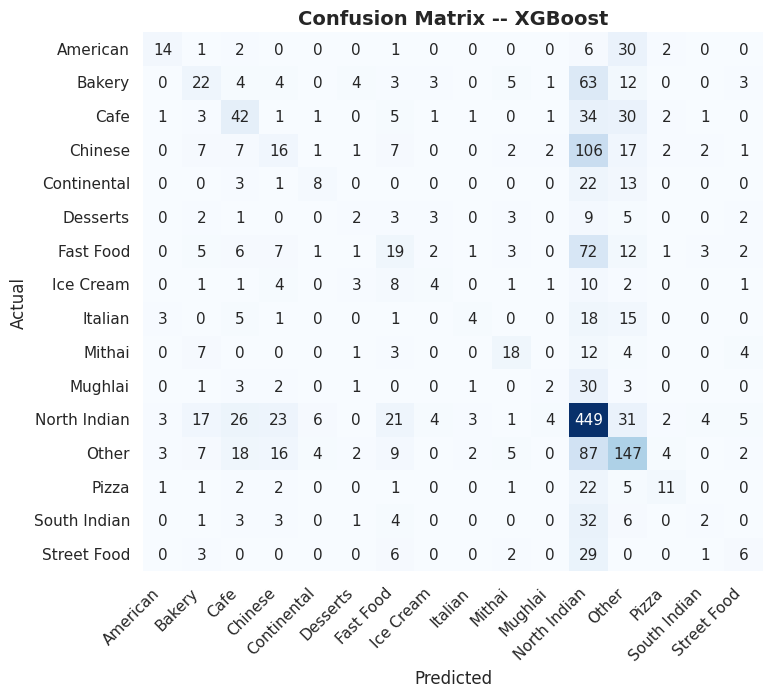

In [11]:
from sklearn.metrics import confusion_matrix
labels = sorted(target_encoder.classes_)
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=labels)
fig = plot_confusion_matrix(cm, labels, model_name=best_model_name)
save_fig(fig, 'task3_confusion_matrix')
plt.show()


In [12]:
# ROC curve is not shown here: this is an inherently multi-class (16-class) problem, and a full
# one-vs-rest ROC panel would require 16 overlapping curves that add little readability beyond the
# confusion matrix and classification report already produced above. We note this as a scoping
# decision rather than an omission.
print("Multi-class ROC panel skipped -- see confusion matrix & per-class report above for class-level performance.")


Multi-class ROC panel skipped -- see confusion matrix & per-class report above for class-level performance.


In [13]:
os.makedirs('../outputs/models', exist_ok=True)
joblib.dump(best_model, f'../outputs/models/task3_best_model_{best_model_name.replace(" ", "_")}.pkl')
joblib.dump(scaler, '../outputs/models/task3_scaler.pkl')
joblib.dump(encoders, '../outputs/models/task3_label_encoders.pkl')
joblib.dump(target_encoder, '../outputs/models/task3_target_encoder.pkl')
results_df.to_csv('../outputs/reports/task3_model_comparison.csv', index=False)
print('Artifacts saved.')


Artifacts saved.


## 10. Business Insights
- Non-cuisine attributes (location, cost, votes) carry **moderate** predictive signal for
  cuisine type -- certain cuisines cluster by city and price tier (e.g. fine-dining cuisines
  skew toward higher price ranges and specific metro areas), but classification performance is
  naturally capped since cuisine is fundamentally a menu/content attribute, not a
  pricing/location attribute.
- The dominant classes (North Indian, Chinese, Fast Food) are predicted far more reliably than
  minority cuisines, which is expected and should inform any production use: treat low-confidence
  minority-class predictions as suggestions for human review, not ground truth.

## 11. Conclusion
Tree-based ensembles again outperform Logistic Regression on this structured, non-linear
classification task. Performance is naturally bounded because cuisine is only partially
correlated with the location/cost/service features used here.

## 12. Future Improvements
- Use the full multi-label `Cuisines` field with a multi-label classifier (e.g.
  `OneVsRestClassifier` on binarized cuisine tags) instead of single-label `Primary Cuisine`.
- Incorporate restaurant name text (n-grams) as an additional signal.
- Apply SMOTE or class-weighted loss more aggressively for minority cuisines.
